### Lab Assignment 1 – KNN Voice Classification


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
data.info()
data['label'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

label
male      1584
female    1584
Name: count, dtype: int64

### 1. Build the KNN model (baseline: all features)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data['label'] = data['label'].map({'male': 1, 'female': 0})

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

y_pred = knn.predict(X_test_s)
print('Accuracy (all 20 features, k=5):', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy (all 20 features, k=5): 0.9737118822292324
Confusion Matrix:
 [[461  15]
 [ 10 465]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       476
           1       0.97      0.98      0.97       475

    accuracy                           0.97       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.97      0.97      0.97       951



### 2. Feature selection experiment

meanfun     0.831008
IQR         0.619419
Q25         0.509777
sp.ent      0.487072
sd          0.481763
sfm         0.363212
centroid    0.335248
meanfreq    0.335248
median      0.276710
mindom      0.193980
maxdom      0.185561
dfrange     0.182190
meandom     0.173419
maxfun      0.169217
mode        0.166714
minfun      0.138812
kurt        0.096165
Q75         0.066212
skew        0.048043
modindx     0.027717
dtype: float64


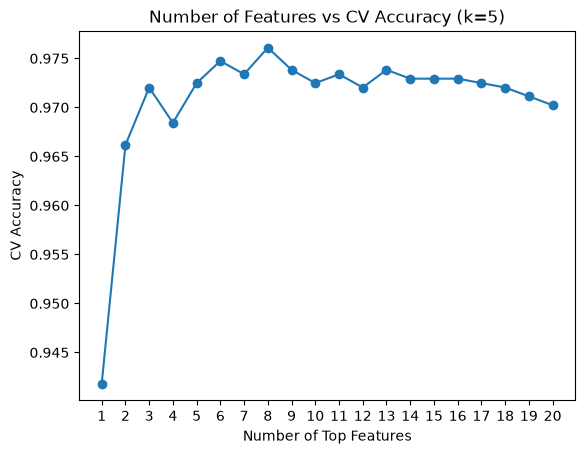

Best number of features: 8
Selected features: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq']
CV accuracy (selected): 0.9760935879446038
CV accuracy (all features): 0.9702255302706769


In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

ranking = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(ranking)

cv_scores = []
for n in range(1, len(ranking) + 1):
    cols = ranking.index[:n]
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    cv_scores.append(cross_val_score(model, X_train[cols], y_train, cv=5).mean())

plt.plot(range(1, len(ranking) + 1), cv_scores, marker='o')
plt.title('Number of Features vs CV Accuracy (k=5)')
plt.xlabel('Number of Top Features')
plt.ylabel('CV Accuracy')
plt.xticks(range(1, len(ranking) + 1))
plt.show()

best_n = int(np.argmax(cv_scores)) + 1
selected = list(ranking.index[:best_n])
print('Best number of features:', best_n)
print('Selected features:', selected)
print('CV accuracy (selected):', max(cv_scores))
print('CV accuracy (all features):', cv_scores[-1])

In [5]:
scaler_sel = StandardScaler()
X_train_sel = scaler_sel.fit_transform(X_train[selected])
X_test_sel = scaler_sel.transform(X_test[selected])

knn_sel = KNeighborsClassifier(n_neighbors=5)
knn_sel.fit(X_train_sel, y_train)

print('Test accuracy (selected features):', knn_sel.score(X_test_sel, y_test))
print('Test accuracy (all features):', knn.score(X_test_s, y_test))

Test accuracy (selected features): 0.9831756046267087
Test accuracy (all features): 0.9737118822292324


**Answer (Question 2):** The best results came from the top 8 features ranked by correlation with the label: `meanfun`, `IQR`, `Q25`, `sp.ent`, `sd`, `sfm`, `centroid`, `meanfreq`. With k=5 these gave a CV accuracy of about 0.976, versus about 0.970 for all 20 features, and a test accuracy of about 0.983 versus 0.974. The curve rises quickly up to the first 3 features (`meanfun` alone is already a strong separator), then stays roughly flat. The low-correlation features (`skew`, `modindx`, `Q75`, `kurt`, ...) add little and mainly add noise to the distance calculation, which KNN is sensitive to.

### 3. Best k for the selected features

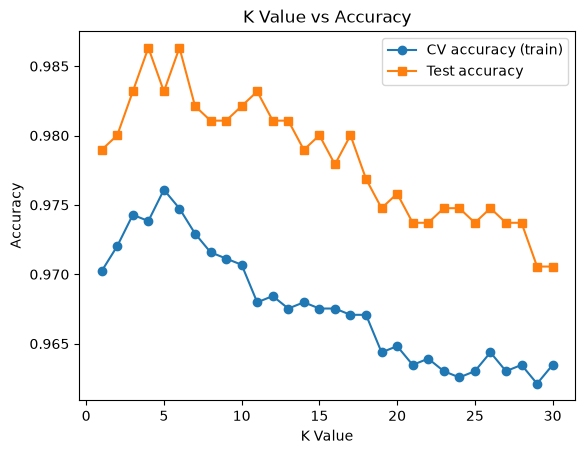

Best k (by CV): 5 -> CV accuracy: 0.9760935879446038


In [6]:
k_range = range(1, 31)
cv_k, test_k = [], []

for k in k_range:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    cv_k.append(cross_val_score(model, X_train[selected], y_train, cv=5).mean())

    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_sel, y_train)
    test_k.append(m.score(X_test_sel, y_test))

plt.plot(k_range, cv_k, marker='o', label='CV accuracy (train)')
plt.plot(k_range, test_k, marker='s', label='Test accuracy')
plt.title('K Value vs Accuracy')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

best_k = int(np.argmax(cv_k)) + 1
print('Best k (by CV):', best_k, '-> CV accuracy:', max(cv_k))

In [7]:
final = KNeighborsClassifier(n_neighbors=best_k)
final.fit(X_train_sel, y_train)
y_pred = final.predict(X_test_sel)

print(f'Final model: k={best_k}, features={len(selected)}')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Final model: k=5, features=8
Accuracy: 0.9831756046267087
Confusion Matrix:
 [[466  10]
 [  6 469]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       476
           1       0.98      0.99      0.98       475

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



**Answer (Question 3):** Using the 8 selected features, the best k chosen by 5-fold cross-validation is **k = 5** (CV accuracy about 0.976). In the K-vs-accuracy graph, very small k fits the noise (k=1 is lower), accuracy peaks at small-to-moderate k, and it slowly declines as k grows because the neighborhood gets too broad and smooths over the class boundary. k=5 balances the two, so it was chosen. On the test set, the final model (k=5, 8 features) reaches about 0.983 accuracy, with 10 females and 6 males misclassified out of 951.